In [65]:
#instalamos lo necesario para hacer graficas
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score
from sklearn.preprocessing import MinMaxScaler

from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
#definimos de cuando a cuando queremos sacar los datos
btc = yf.download('BTC-USD', start='2020-01-01', end='2026-04-01')
eth = yf.download('ETH-USD', start='2020-01-01', end='2026-04-01')

#vemos los datos
btc.head(20)

/tmp/ipykernel_6911/2197296264.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', start='2020-01-01', end='2026-04-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6911/2197296264.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download('ETH-USD', start='2020-01-01', end='2026-04-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095
2020-01-06,7769.219238,7781.867188,7409.292969,7410.452148,23276261598
2020-01-07,8163.692383,8178.215820,7768.227539,7768.682129,28767291327
2020-01-08,8079.862793,8396.738281,7956.774414,8161.935547,31672559265


In [67]:
# Nos quedamos con precios de cierre
btc = btc[['Close']].rename(columns={'Close': 'BTC'})
eth = eth[['Close']].rename(columns={'Close': 'ETH'})

# Unir datasets
data = pd.concat([btc, eth], axis=1)

# Eliminar valores nulos
data.dropna(inplace=True)


data.head(20)

Price,BTC,ETH
Ticker,BTC-USD,ETH-USD
Date,,
2020-01-01,7200.174316,130.802002
2020-01-02,6985.470215,127.410179
2020-01-03,7344.884277,134.171707
2020-01-04,7410.656738,135.069366
2020-01-05,7411.317383,136.276779
2020-01-06,7769.219238,144.304153
2020-01-07,8163.692383,143.543991
2020-01-08,8079.862793,141.258133


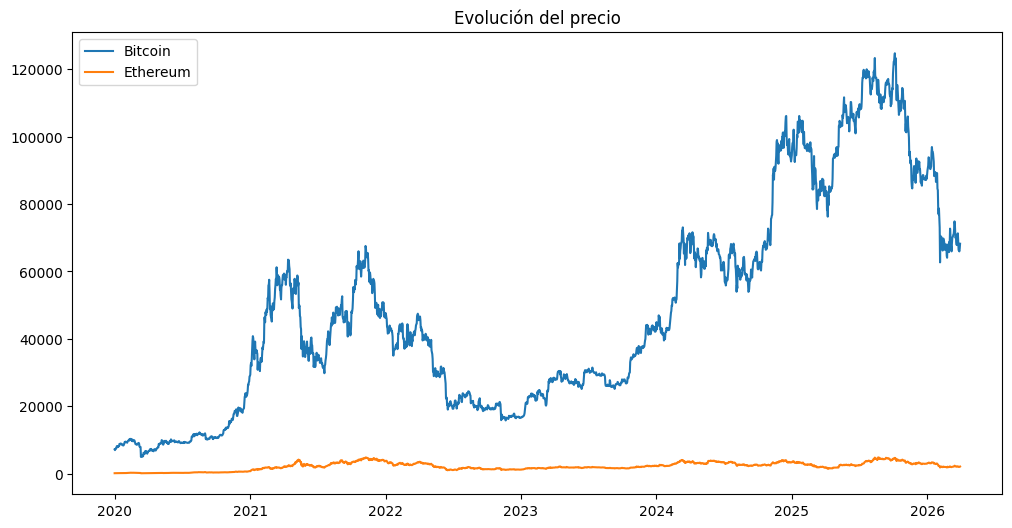

In [68]:
plt.figure(figsize=(12,6))
plt.plot(data['BTC'], label='Bitcoin')
plt.plot(data['ETH'], label='Ethereum')
plt.title('Evolución del precio')
plt.legend()
plt.show()

In [69]:
returns = data.pct_change().dropna()
returns.head()

Price,BTC,ETH
Ticker,BTC-USD,ETH-USD
Date,,
2020-01-02,-0.029819,-0.025931
2020-01-03,0.051452,0.053069
2020-01-04,0.008955,0.006690
2020-01-05,0.000089,0.008939
2020-01-06,0.048291,0.058905


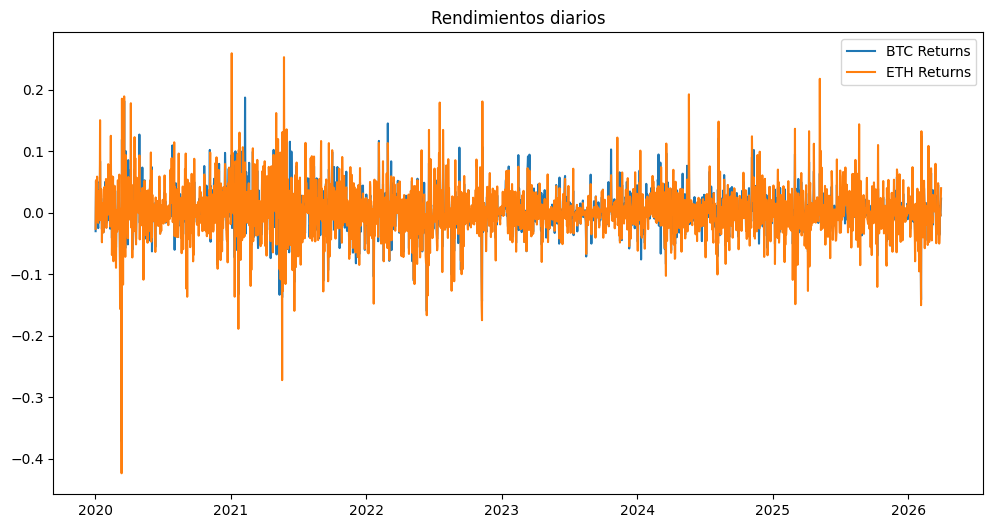

In [70]:
plt.figure(figsize=(12,6))
plt.plot(returns['BTC'], label='BTC Returns')
plt.plot(returns['ETH'], label='ETH Returns')
plt.title('Rendimientos diarios')
plt.legend()
plt.show()

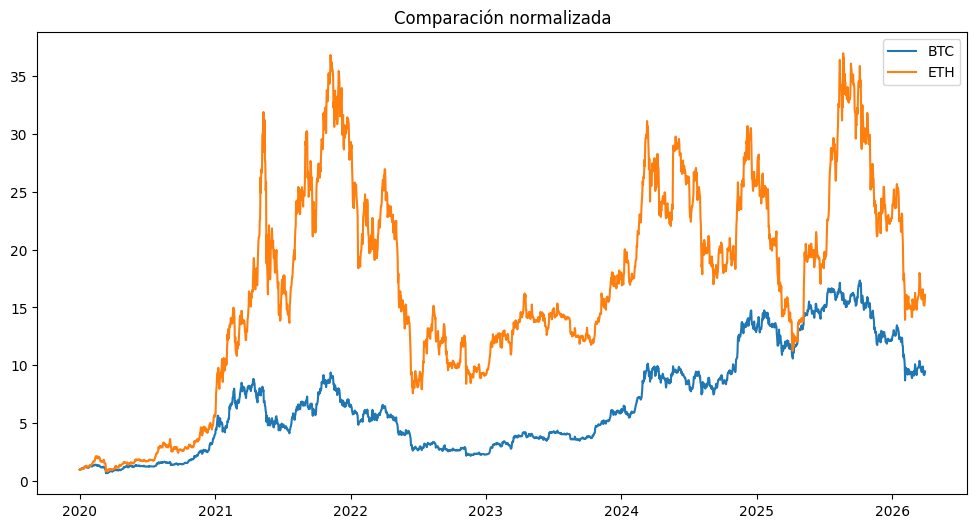

In [71]:
normalized = data / data.iloc[0]

plt.figure(figsize=(12,6))
plt.plot(normalized['BTC'], label='BTC')
plt.plot(normalized['ETH'], label='ETH')
plt.title('Comparación normalizada')
plt.legend()
plt.show()

In [72]:
correlation = returns.corr()
print(correlation)

Price              BTC      ETH
Ticker         BTC-USD  ETH-USD
Price Ticker                   
BTC   BTC-USD  1.00000  0.81785
ETH   ETH-USD  0.81785  1.00000
